In [1]:
import os
from time import sleep
from tqdm import tqdm

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler

from keras.models import Model, load_model
from keras.layers import Input, Dense, LSTM, RepeatVector, TimeDistributed
from keras import regularizers

from matplotlib import pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

C:\Users\nicho\AppData\Local\Temp\ipykernel_253532\1763472020.py:6: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
base_path = '/Users/nicholastey/Desktop/thesis/gnss_spoof_detector/spoof_detector/data/'
base_path = 'C:/Users/nicho/Desktop/gnss_spoof_detector/spoof_detector/data'

In [3]:
cs_path, ds1_path, ds3_path, ds2_path, ds4_path, ds7_path, ds8_path = [os.path.join(base_path, ds_path) for ds_path in os.listdir(base_path)]


In [4]:
columns = ['channel', 'prn', 'acq_doopler_hz', 'acq_doppler_step', 'fs', 'prompt_i', 'prompt_q', 'cn0_db_hz', 'carrier_doppler_hz', 'pseudorange_m', 'rx_time']

for ds_fname in os.listdir(base_path):
  tmp_path = os.path.join(base_path, ds_fname)
  key = ds_fname.split('.')[0]
  
  tmp_df = pd.read_csv(tmp_path, header=None)
  prn_li = []
  for i in range(8):
    prn_li.append(int(tmp_df.iloc[1, 11*i+1]))
  globals()[f'{key}_dict'] = {
      int(f'{prn_li[0]}') : tmp_df.iloc[100:, 0:9].rename(columns=lambda x: columns[x%11]).iloc[:, 5:].fillna(0),
      int(f'{prn_li[1]}') : tmp_df.iloc[100:, 11:20].rename(columns=lambda x: columns[x%11]).iloc[:, 5:].fillna(0),
      int(f'{prn_li[2]}') : tmp_df.iloc[100:, 22:31].rename(columns=lambda x: columns[x%11]).iloc[:, 5:].fillna(0),
      int(f'{prn_li[3]}') : tmp_df.iloc[100:, 33:42].rename(columns=lambda x: columns[x%11]).iloc[:, 5:].fillna(0),
      int(f'{prn_li[4]}') : tmp_df.iloc[100:, 44:53].rename(columns=lambda x: columns[x%11]).iloc[:, 5:].fillna(0),
      int(f'{prn_li[5]}') : tmp_df.iloc[100:, 55:64].rename(columns=lambda x: columns[x%11]).iloc[:, 5:].fillna(0),
      int(f'{prn_li[6]}') : tmp_df.iloc[100:, 66:75].rename(columns=lambda x: columns[x%11]).iloc[:, 5:].fillna(0),
      int(f'{prn_li[7]}') : tmp_df.iloc[100:, 77:86].rename(columns=lambda x: columns[x%11]).iloc[:, 5:].fillna(0),
      'prn' : prn_li
  }

dicts = [cs_dict, ds1_dict, ds2_dict, ds3_dict, ds4_dict, ds7_dict, ds8_dict]

In [5]:
big_df = []

dicts_with_labels = [
    (cs_dict, 0),  # Clean
    (ds1_dict, 1),
    (ds2_dict, 2),
    (ds3_dict, 3),
    (ds4_dict, 4),
    (ds7_dict, 5),
    (ds8_dict, 6)
]

for dataset, label in dicts_with_labels:
    for prn in dataset['prn']:
        df = dataset[prn].copy()
        df['spoofed'] = label
        df['prn'] = prn
        big_df.append(df)

# big_df = pd.concat(big_df, ignore_index=True)
# print(big_df.shape)
# print(big_df.columns)
# print(big_df['spoofed'].value_counts(normalize=True))

# big_df

In [6]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --------------------------------------------
# 0) Helper(s)
# --------------------------------------------
def _rolling_slope(y: np.ndarray) -> float:
    n = len(y)
    if n < 2:
        return np.nan
    x = np.arange(n, dtype=float)
    x = x - x.mean()
    y = y.astype(float)
    # robust to NaNs
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 2:
        return np.nan
    x = x[mask]; y = y[mask]
    denom = np.dot(x, x)
    if denom == 0:
        return 0.0
    return float(np.dot(x, y - y.mean()) / denom)

# --------------------------------------------
# 1) Build per-dict samples + skip head + seq = 1..N
# --------------------------------------------
def build_samples(dicts_with_labels, skip_head: int = 100):
    """
    Build per-scenario DFs, drop first `skip_head` rows per (sample_id, prn),
    then assign 1..N 'seq' as pseudo-time.
    """
    samples = []
    for sid, (dataset, label) in enumerate(dicts_with_labels):
        dfs = []
        for prn in dataset['prn']:
            g = dataset[prn].copy().reset_index(drop=True)

            # metadata
            g['sample_id'] = sid
            g['spoofed']   = label
            g['prn']       = prn

            # drop the first N rows for THIS (sid, prn)
            if skip_head > 0 and len(g) > 0:
                g = g.iloc[skip_head:, :]

            # pseudo-time AFTER trimming: 1..len(g)
            if len(g) > 0:
                g['seq'] = np.arange(1, len(g) + 1, dtype=np.int64)

            dfs.append(g)

        samples.append(pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame())
    return samples

# knob: how many early samples to ignore per (scenario, PRN)
SKIP_HEAD_PRN = 100
samples = build_samples(dicts_with_labels, skip_head=SKIP_HEAD_PRN)

# --------------------------------------------
# 2) Drift-focused I/Q feature engineering
# --------------------------------------------
def add_iq_drift_features(df: pd.DataFrame, window: int = 128, eps: float = 1e-9) -> pd.DataFrame:
    """
    Adds drift-sensitive features in the complex plane z = I + jQ,
    ordered by 'seq' within each (sample_id, prn).
    Required cols: prompt_i, prompt_q, sample_id, prn, seq
    """
    required = {'prompt_i','prompt_q','sample_id','prn','seq'}
    missing = required - set(df.columns)
    if missing:
        raise KeyError(f"Missing columns for drift features: {missing}")

    out = df.sort_values(['sample_id','prn','seq']).copy()

    # Base polar quantities
    out['mag'] = np.hypot(out['prompt_i'], out['prompt_q'])

    # Phase (unwrapped) per group
    def _unwrap_phase(g):
        ph = np.arctan2(g['prompt_q'].to_numpy(), g['prompt_i'].to_numpy())
        return pd.Series(np.unwrap(ph), index=g.index)
    out['phase'] = out.groupby(['sample_id','prn'], sort=False).apply(_unwrap_phase).reset_index(level=[0,1], drop=True)

    # Phase increment
    out['dphase'] = out.groupby(['sample_id','prn'], sort=False)['phase'].diff().fillna(0.0)

    # Step-wise path length in complex plane
    dI = out.groupby(['sample_id','prn'], sort=False)['prompt_i'].diff()
    dQ = out.groupby(['sample_id','prn'], sort=False)['prompt_q'].diff()
    step_len = np.hypot(dI, dQ).fillna(0.0)
    out['pathlen_w'] = step_len.groupby([out['sample_id'], out['prn']], sort=False) \
                               .rolling(window, min_periods=2).sum().reset_index(level=[0,1], drop=True)

    # Net displacement over window
    I_lag = out.groupby(['sample_id','prn'], sort=False)['prompt_i'].shift(window-1)
    Q_lag = out.groupby(['sample_id','prn'], sort=False)['prompt_q'].shift(window-1)
    out['net_disp_w'] = np.hypot(out['prompt_i'] - I_lag, out['prompt_q'] - Q_lag)

    # Tortuosity: path length / net displacement
    out['tortuosity_w'] = out['pathlen_w'] / (out['net_disp_w'] + eps)

    # Rolling stats of phase increment
    out['dphase_mean_w'] = out.groupby(['sample_id','prn'], sort=False)['dphase'] \
                              .rolling(window, min_periods=5).mean().reset_index(level=[0,1], drop=True)
    out['dphase_std_w']  = out.groupby(['sample_id','prn'], sort=False)['dphase'] \
                              .rolling(window, min_periods=5).std().reset_index(level=[0,1], drop=True)

    # Rolling trend proxies (linear slope) of phase and magnitude
    out['phase_slope_w'] = out.groupby(['sample_id','prn'], sort=False)['phase'] \
                              .rolling(window, min_periods=5).apply(_rolling_slope, raw=True).reset_index(level=[0,1], drop=True)
    out['mag_slope_w']   = out.groupby(['sample_id','prn'], sort=False)['mag'] \
                              .rolling(window, min_periods=5).apply(_rolling_slope, raw=True).reset_index(level=[0,1], drop=True)

    # Covariance ellipse anisotropy over the window (major/minor eigenvalue ratio)
    def _ellipse_ratio_group(g):
        I = g['prompt_i'].to_numpy()
        Q = g['prompt_q'].to_numpy()
        n = len(g)
        out_arr = np.full(n, np.nan, dtype=float)
        if n < 5:
            return pd.Series(out_arr, index=g.index)
        for t in range(n):
            s = max(0, t - (window - 1))
            m = t - s + 1
            if m < 5:
                continue
            Ii = I[s:t+1]
            Qi = Q[s:t+1]
            C = np.cov(np.vstack([Ii, Qi]))
            if not np.isfinite(C).all():
                continue
            vals = np.linalg.eigvalsh(C)
            if vals[0] <= 0 or vals[1] <= 0:
                continue
            out_arr[t] = float(vals[1] / vals[0])
        return pd.Series(out_arr, index=g.index)

    out['ellipse_ratio_w'] = out.groupby(['sample_id','prn'], sort=False).apply(_ellipse_ratio_group).reset_index(level=[0,1], drop=True)
    return out

# add features per scenario DF
DRIFT_WINDOW = 128  # try 64 / 128 / 256
samples = [add_iq_drift_features(df, window=DRIFT_WINDOW) for df in samples]

# --------------------------------------------
# 3) Split PRNs within each scenario (as you had)
# --------------------------------------------
def split_prns_within_sample(df, train_ratio=0.6, val_ratio=0.2, rnd=42):
    prns = df['prn'].unique()
    tr_prn, te_prn = train_test_split(prns, test_size=1-train_ratio, random_state=rnd, shuffle=True)
    rel = np.setdiff1d(prns, tr_prn)
    val_size = int(round(val_ratio * len(prns)))
    val_size = max(1, min(len(rel)-1, val_size)) if len(rel) >= 2 else len(rel)
    va_prn, te_prn = train_test_split(rel, test_size=len(rel)-val_size, random_state=rnd, shuffle=True)
    return set(tr_prn), set(va_prn), set(te_prn)

train_rows, val_rows, test_rows = [], [], []
for df in samples:
    trp, vap, tep = split_prns_within_sample(df, train_ratio=0.6, val_ratio=0.2, rnd=42)
    train_rows.append(df[df['prn'].isin(trp)])
    val_rows.append(  df[df['prn'].isin(vap)])
    test_rows.append( df[df['prn'].isin(tep)])

df_train = pd.concat(train_rows, ignore_index=True)
df_val   = pd.concat(val_rows,   ignore_index=True)
df_test  = pd.concat(test_rows,  ignore_index=True)

# --------------------------------------------
# 4) Feature set & scaling (fit on TRAIN only)
# --------------------------------------------
feature_cols = [
    'prompt_i','prompt_q','mag','phase','dphase',
    'pathlen_w','net_disp_w','tortuosity_w',
    'dphase_mean_w','dphase_std_w',
    'phase_slope_w','mag_slope_w','ellipse_ratio_w'
]

scaler = StandardScaler().fit(df_train[feature_cols].values)

def scale_df(df):
    Xs = scaler.transform(df[feature_cols].values)
    Xs = pd.DataFrame(Xs, index=df.index, columns=feature_cols)
    # keep identifiers and ordering key
    return Xs.join(df[['spoofed','prn','sample_id','seq']])

df_train_s = scale_df(df_train)
df_val_s   = scale_df(df_val)
df_test_s  = scale_df(df_test)

# --------------------------------------------
# 5) Sequence maker (uses seq ordering)
# --------------------------------------------
def make_sequences(df, time_steps=100, step=1, feat_cols=feature_cols, label_col='spoofed'):
    Xs, ys = [], []
    df_sorted = df.sort_values(['sample_id','prn','seq'])
    for _, g in df_sorted.groupby(['sample_id','prn'], sort=False):
        Xg = g[feat_cols].to_numpy()
        yg = g[label_col].to_numpy()
        n = len(g)
        if n < time_steps:
            continue
        for i in range(0, n - time_steps + 1, step):
            Xs.append(Xg[i:i+time_steps])
            ys.append(yg[i+time_steps-1])
    return np.asarray(Xs), np.asarray(ys)

# knobs
TIME_STEPS = 100
X_tr, y_tr = make_sequences(df_train_s, time_steps=TIME_STEPS)
X_va, y_va = make_sequences(df_val_s,   time_steps=TIME_STEPS)
X_te, y_te = make_sequences(df_test_s,  time_steps=TIME_STEPS)

# X_tr, y_tr, X_va, y_va, X_te, y_te are now ready for your model


C:\Users\nicho\AppData\Local\Temp\ipykernel_253532\3436212403.py:85: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out['phase'] = out.groupby(['sample_id','prn'], sort=False).apply(_unwrap_phase).reset_index(level=[0,1], drop=True)
C:\Users\nicho\AppData\Local\Temp\ipykernel_253532\3436212403.py:141: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out['ellipse_ratio_w'] = out.groupby(['sample_id','prn'], sort

In [7]:
X_tr

array([[[ 1.17821021,  0.95765794,  0.585094  , ...,         nan,
                 nan,         nan],
        [ 1.17821021,  0.95765794,  0.585094  , ...,         nan,
                 nan,         nan],
        [ 1.17821021,  0.95765794,  0.585094  , ...,         nan,
                 nan,         nan],
        ...,
        [-1.1130292 ,  0.15735747,  0.53954954, ...,  0.37411567,
         -0.2781885 , -0.00584975],
        [-1.1130292 ,  0.15735747,  0.53954954, ...,  0.33182651,
         -0.26041314, -0.00584975],
        [-1.1130292 ,  0.15735747,  0.53954954, ...,  0.29184801,
         -0.24353836, -0.00584975]],

       [[ 1.17821021,  0.95765794,  0.585094  , ...,         nan,
                 nan,         nan],
        [ 1.17821021,  0.95765794,  0.585094  , ...,         nan,
                 nan,         nan],
        [ 1.17821021,  0.95765794,  0.585094  , ...,         nan,
                 nan,         nan],
        ...,
        [-1.1130292 ,  0.15735747,  0.53954954, ...,  

In [8]:
import pywt

def apply_swt_per_sequence(X_seq, wavelet='db4', level=1, include_approx=True):
    """
    Apply Stationary Wavelet Transform (SWT) to each sequence.
    Keeps time alignment so output is suitable for LSTM.

    Input:
        X_seq: shape (n_windows, time_steps, n_features)
    Output:
        X_wavelet: shape (n_windows, time_steps, n_features_transformed)
    """
    X_wavelet = []

    for sequence in X_seq:  # (time_steps, n_features)
        seq_features = []
        for i in range(sequence.shape[1]):  # for each feature
            coeffs = pywt.swt(sequence[:, i], wavelet=wavelet, level=level, start_level=0)
            # coeffs = list of (cA, cD), each length = time_steps
            detail_list = [cD for (cA, cD) in coeffs]
            if include_approx:
                detail_list.append(coeffs[-1][0])  # final approximation
            feature_matrix = np.stack(detail_list, axis=1)  # (time_steps, n_coeffs_per_feature)
            seq_features.append(feature_matrix)
        # concat all features along last axis
        seq_features = np.concatenate(seq_features, axis=1)  # (time_steps, n_features * n_coeffs_per_feature)
        X_wavelet.append(seq_features)

    return np.array(X_wavelet)



In [9]:
X_tr_w = apply_swt_per_sequence(X_tr)
X_va_w = apply_swt_per_sequence(X_va)
X_te_w = apply_swt_per_sequence(X_te)


In [10]:
from tensorflow.keras.layers import LSTM, Dropout, Dense, BatchNormalization, Bidirectional, Input, Conv1D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau

def create_lstm_model(input_shape):
    inputs = Input(shape=input_shape)
    # x = Conv1D(128, kernel_size=16, activation='relu', padding='same')(inputs)
    # x = Conv1D(64, kernel_size=12, activation='relu', padding='same')(x)
    # x = Conv1D(32, kernel_size=3, activation='relu', padding='same')(x)
    # x = layers.LayerNormalization()(x)  # Layer Normalization
    x = LSTM(64, return_sequences=True, recurrent_dropout=0.15)(inputs)
    x = Dropout(0.4)(x)  # Increased dropout
    x = LSTM(32, return_sequences=False, recurrent_dropout=0.15)(x)
    x = Dropout(0.4)(x)  # Increased dropout
    x = Dense(25, activation='relu')(x)
    x = Dropout(0.5)(x)  # Increased dropout
    x = Dense(12, activation='relu')(x)
    # x = BatchNormalization()(x)  # Batch Normalization
    outputs = Dense(7, activation='softmax')(x)

    model = Model(inputs, outputs)
    optimizer = Adam(learning_rate=0.01)  # Lower learning rate
    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    
    return model

lr_schedule = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)


In [14]:
lstm_model = create_lstm_model((X_tr.shape[1], X_tr.shape[2]))

In [15]:
# Train LSTM model
lstm_model.fit(X_tr, y_tr, 
               validation_data=(X_va, y_va), 
               epochs=35, 
               batch_size=500, 
               verbose=1,
               callbacks=[lr_schedule])

Epoch 1/35
179/179 ━━━━━━━━━━━━━━━━━━━━ 24s 128ms/step - accuracy: 0.1460 - loss: 1.9467 - val_accuracy: 0.1454 - val_loss: 1.9459 - learning_rate: 0.0100
Epoch 2/35
179/179 ━━━━━━━━━━━━━━━━━━━━ 23s 127ms/step - accuracy: 0.1465 - loss: 1.9457 - val_accuracy: 0.1440 - val_loss: 1.9462 - learning_rate: 0.0100
Epoch 3/35
179/179 ━━━━━━━━━━━━━━━━━━━━ 24s 131ms/step - accuracy: 0.1450 - loss: 1.9461 - val_accuracy: 0.1472 - val_loss: 1.9455 - learning_rate: 0.0100
Epoch 4/35
179/179 ━━━━━━━━━━━━━━━━━━━━ 23s 129ms/step - accuracy: 0.1508 - loss: 1.9455 - val_accuracy: 0.1472 - val_loss: 1.9456 - learning_rate: 0.0100
Epoch 5/35
179/179 ━━━━━━━━━━━━━━━━━━━━ 23s 131ms/step - accuracy: 0.1449 - loss: 1.9458 - val_accuracy: 0.1454 - val_loss: 1.9457 - learning_rate: 0.0100
Epoch 6/35
178/179 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.1463 - loss: 1.9458
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.004999999888241291.
179/179 ━━━━━━━━━━━━━━━━━━━━ 23s 129ms/step - accuracy: 0.1463

1305/1305 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.2071 - loss: 19.1863
LSTM Test Loss: 25.4665, Test Accuracy: 0.1906
1305/1305 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step
              precision    recall  f1-score   support

           0       0.01      0.00      0.01      5676
           1       0.90      0.51      0.65      6076
           2       0.14      0.49      0.22      5924
           3       0.08      0.14      0.10      5732
           4       0.01      0.00      0.00      6012
           5       0.00      0.00      0.00      6156
           6       1.00      0.18      0.30      6156

    accuracy                           0.19     41732
   macro avg       0.30      0.19      0.18     41732
weighted avg       0.31      0.19      0.19     41732



Text(95.72222222222221, 0.5, 'True Label')

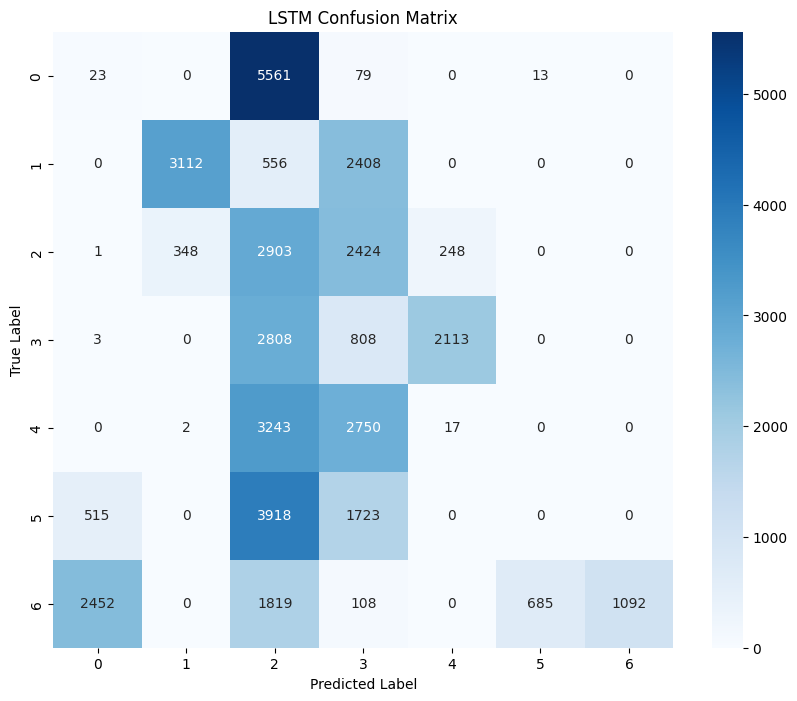

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Evaluate LSTM model
lstm_loss, lstm_accuracy = lstm_model.evaluate(X_te_w, y_te, verbose=1)
print(f"LSTM Test Loss: {lstm_loss:.4f}, Test Accuracy: {lstm_accuracy:.4f}")
y_pred_lstm = np.argmax(lstm_model.predict(X_te_w), axis=1)
print(classification_report(y_te, y_pred_lstm))
cm_lstm = confusion_matrix(y_te, y_pred_lstm)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Blues')
plt.title('LSTM Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')


In [17]:
from tensorflow.keras import layers, models, Input

def tcn_block(x, filters, kernel_size=3, dilation_rate=1, dropout=0.2):
    # First dilated conv
    conv1 = layers.Conv1D(filters, kernel_size, padding='causal',
                          dilation_rate=dilation_rate, activation='relu')(x)
    conv1 = layers.Dropout(dropout)(conv1)

    # Second dilated conv
    conv2 = layers.Conv1D(filters, kernel_size, padding='causal',
                          dilation_rate=dilation_rate, activation='relu')(conv1)

    # Residual connection (adjust dims if needed)
    if x.shape[-1] != filters:
        x = layers.Conv1D(filters, 1, padding='same')(x)
    out = layers.add([conv2, x])
    out = layers.LayerNormalization()(out)
    return out

def create_tcn_model(input_shape, num_classes=7):
    inputs = Input(shape=input_shape)

    # Stack residual blocks with increasing dilation
    x = tcn_block(inputs, filters=64, dilation_rate=1)
    x = tcn_block(x, filters=64, dilation_rate=2)
    x = tcn_block(x, filters=64, dilation_rate=4)

    # Global pooling to collapse time
    x = layers.GlobalAveragePooling1D()(x)

    # Dense head
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs)
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model



In [ ]:
tcn_model = create_tcn_model((X_tr.shape[1], X_tr.shape[2]))

history = tcn_model.fit(X_tr, y_tr, 
               validation_data=(X_va, y_va), 
               epochs=35,
               batch_size=64,
               verbose=1,
               callbacks=[lr_schedule])

Epoch 1/35
1392/1392 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.1475 - loss: 1.9468 - val_accuracy: 0.1472 - val_loss: 1.9455 - learning_rate: 0.0010
Epoch 2/35
1392/1392 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - accuracy: 0.1459 - loss: 1.9456 - val_accuracy: 0.1472 - val_loss: 1.9455 - learning_rate: 0.0010
Epoch 3/35
1392/1392 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - accuracy: 0.1474 - loss: 1.9458 - val_accuracy: 0.1472 - val_loss: 1.9455 - learning_rate: 0.0010
Epoch 4/35
1392/1392 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.1457 - loss: 1.9457
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1392/1392 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - accuracy: 0.1457 - loss: 1.9457 - val_accuracy: 0.1472 - val_loss: 1.9456 - learning_rate: 0.0010
Epoch 5/35
1390/1392 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.1460 - loss: 1.9455

1305/1305 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step
              precision    recall  f1-score   support

           0       0.12      0.13      0.13      5676
           1       0.87      0.85      0.86      6076
           2       0.15      0.50      0.23      5924
           3       0.20      0.15      0.17      5732
           4       0.03      0.02      0.02      6012
           5       0.00      0.00      0.00      6156
           6       0.00      0.00      0.00      6156

    accuracy                           0.24     41732
   macro avg       0.20      0.24      0.20     41732
weighted avg       0.20      0.24      0.20     41732



Text(95.72222222222221, 0.5, 'True Label')

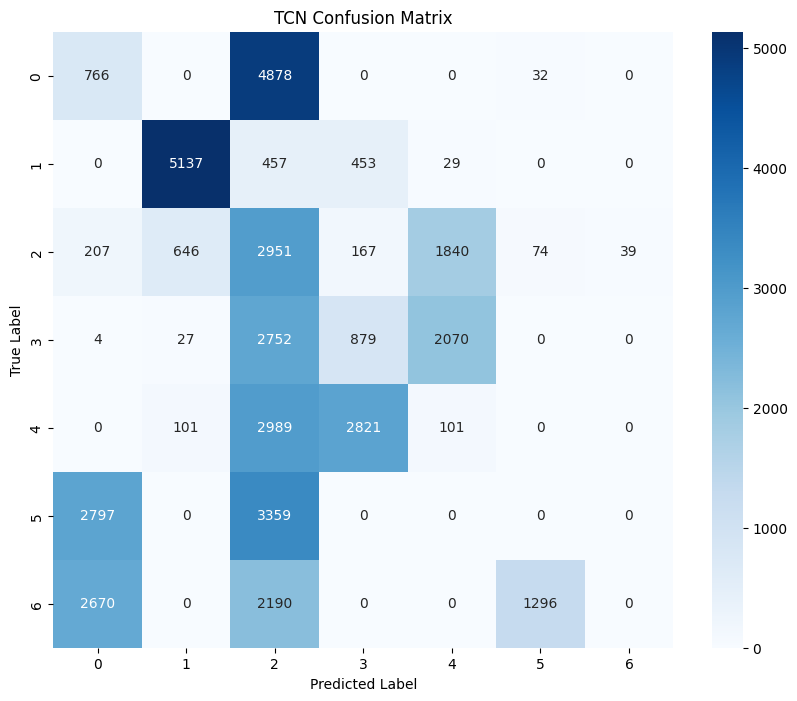

In [ ]:
y_pred_tcn = np.argmax(tcn_model.predict(X_te_w), axis=1)
print(classification_report(y_te, y_pred_tcn))
cm_tcn = confusion_matrix(y_te, y_pred_tcn)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_tcn, annot=True, fmt='d', cmap='Blues')
plt.title('TCN Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
